Authors:

- Michiel Rollier
- João Vitor Merenda
- Lucas Caldeira de Oliveira

In [22]:
import torch as tc
import igraph as ig
import numpy as np
from matplotlib import pyplot as plt

In [2]:
from src.datasets import NetworkDataset
from src.automata import LLNA
from src.simulation import *

# 0 - Table of Symbols

- $G = (V,E)$: a simple graph defined based on its nodes and edges
- $V = \{v\}$: set of nodes;
- $E = \{(v_i,v_j)\}$: set of unweighted edges;
- $\mathbf{A} = [a_{i,j}] \in \{0;1\}^{|V| \times |V|}$: binary adjacency matrix where $a_{i,j} = 1$ denotes the existence of the edge $(v_i,v_j)$;
- $\mathcal{C} = \langle \mathcal{T}, \mathbb{S}, \vec{s}_0, \Phi \rangle$: automaton defined on a tesselation $\mathcal{T}$, a set of discrete states $\mathbb{S}$, an initial configuration $\vec{s}_0$ and a transition function $\Phi$;
- $\vec{s}_t = [s_{i,t}] \in \mathbb{S}^{|V|}$: state vector of $i$-th nodes at time step $t$;
- $\vec{s}^*_t = \vec{s}_t \oplus \delta\vec{s}$: distubed state vector at time step $t$ by the module-$|\mathbb{S}|$ addition with a perturbation vector;
- $\mathbf{H} = [\vec{s}_t] \in \mathbb{S}^{|V| \times T}$ state matrix of nodes evolved by $T$ steps (i.e. time evolution patterns);

# 1 - Introduction

## 1.1 - Cellular Automata, graph theory and network automata

## 1.2 - Definition, interpretation and relevance of robustness

$G = G(V,E)$

<hr>

# 2 - Methods

## 2.1 - Graph setup

Given a complex network model $\mathcal{M}$, a number of samples (graphs) per model $N_\text{samples}$, a number of nodes per graph $N_\text{nodes} = |V|$ and a number of initial configurations per sample $N_\text{init}$, we generate a set of graphs $\mathcal{G}^\mathcal{M} = \{ G(\mathbf{A}, \mathbf{S}_0) \}$, where $\mathbf{A} \in\ \{0;1\}^{N_\text{nodes} \times N_\text{nodes}}$ is the adjacency matrix, $\mathbf{S}_0 = [\vec{s}_0] \in \mathbb{S}^{N_\text{init} \times N_\text{nodes}}$ is the node's state matrix at the initial step $t = 0$ and the cardinality of the set is $\left| \mathcal{G}^\mathcal{M} \right| = N_\text{samples}$.


The state vector can be evolved at discrete time steps by applying the automaton, $\vec{s}_{t+1} = \mathcal{C}(\vec{s}_{t}) \in \mathbb{S}^{|V|}$. Similarly, in matricial notation, we can evolve multiple $L$ state configurations (like original and disturbed setups) by $\mathbf{S}_{t+1} = \mathcal{C}(\mathbf{S}_{t}) \in \mathbb{S}^{L \times |V|}$. Then, we can generalize the time evolution pattern matrix in terms of $\mathbf{S}$ to acomodate any number of $L$ simultaneously simulated scenarios, like $\mathbf{H} \in \mathbb{S}^{L \times |V| \times T}$.



As we are interested in assess how initial perturbations (disturbs) propagate through the network given an automaton, the number $L$ will denote the inicial configuration plus $|V|$ unitary perturbations (one at each node), so $L = 1 + |V|$ when doing an exhaustive experiment. It's also possible to randomly sample a subset of nodes $\tilde{V} \subset V$ to disturb and, by ensuring $|\tilde{V}| \ll |V|$, reduce drasticaly the computational cost to $L = 1 + |\tilde{V}|$ scenarios per automaton.

In [3]:
dataset = NetworkDataset(path='data/graphs', cached=False)

In [4]:
E, h0 = dataset[10]
E.shape, h0.shape

(torch.Size([2, 390]), torch.Size([5, 100]))

In [5]:
automaton = LLNA(resolution=4, x=[1,3], y=[0,2])
str(automaton)

'R=4:B13_S02'

In [6]:
# for each initial condition, create a set of N orthogonal perturbations
# and append to the original init. cond.
H0 = tc.stack([ orth_disturbs(h, True) for h in h0 ], 0)
print(H0.shape)

# join together the first two dimensions
H0 = prepare_shape(H0)
print(H0.shape)

# run the automaton
H = automaton(E, H0, T=3)
print(H.shape)

# separate the first dimension in two
H = restore_shape(H)
print(H.shape)

torch.Size([5, 101, 100])
torch.Size([505, 100])
torch.Size([505, 4, 100])
torch.Size([5, 101, 4, 100])


In [7]:
# check if the initial condition vectors are in the desired place
for i, hi in enumerate(h0):
    print(~(hi != H[i, 0, 0]).any())

tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)


## 2.2 - Network automata rules

In [24]:
for R in range(2,4):
    for i, (X,Y) in enumerate(all_rules_from(R, 2)):
        automaton = LLNA(R, X, Y)
        print(f'[#{i+1:03d}] ', str(automaton))
    print()

[#001]  R=2:B_S
[#002]  R=2:B_S0
[#003]  R=2:B_S1
[#004]  R=2:B_S01
[#005]  R=2:B0_S
[#006]  R=2:B0_S0
[#007]  R=2:B0_S1
[#008]  R=2:B0_S01
[#009]  R=2:B1_S
[#010]  R=2:B1_S0
[#011]  R=2:B1_S1
[#012]  R=2:B1_S01
[#013]  R=2:B01_S
[#014]  R=2:B01_S0
[#015]  R=2:B01_S1
[#016]  R=2:B01_S01

[#001]  R=3:B_S
[#002]  R=3:B_S0
[#003]  R=3:B_S1
[#004]  R=3:B_S2
[#005]  R=3:B_S01
[#006]  R=3:B_S02
[#007]  R=3:B_S12
[#008]  R=3:B_S012
[#009]  R=3:B0_S
[#010]  R=3:B0_S0
[#011]  R=3:B0_S1
[#012]  R=3:B0_S2
[#013]  R=3:B0_S01
[#014]  R=3:B0_S02
[#015]  R=3:B0_S12
[#016]  R=3:B0_S012
[#017]  R=3:B1_S
[#018]  R=3:B1_S0
[#019]  R=3:B1_S1
[#020]  R=3:B1_S2
[#021]  R=3:B1_S01
[#022]  R=3:B1_S02
[#023]  R=3:B1_S12
[#024]  R=3:B1_S012
[#025]  R=3:B2_S
[#026]  R=3:B2_S0
[#027]  R=3:B2_S1
[#028]  R=3:B2_S2
[#029]  R=3:B2_S01
[#030]  R=3:B2_S02
[#031]  R=3:B2_S12
[#032]  R=3:B2_S012
[#033]  R=3:B01_S
[#034]  R=3:B01_S0
[#035]  R=3:B01_S1
[#036]  R=3:B01_S2
[#037]  R=3:B01_S01
[#038]  R=3:B01_S02
[#039]  R=3:

## 2.3 - Time-evolution patterns and graph centrality measures

By evolving an NA over a graph, we may collect the dynamics of the states of the nodes, i.e. all $\vec{s}_{t}$, in a so-called time-evolution pattern (TEP). This is a two-dimensional representation of the NA that is highly reminiscent of a spacetime diagram for a cellular automaton. The difference, however, is that a graph does not impose a regular spatial structure between its nodes. This implies that one needs to make a choice regarding how to order the nodes from left to right in the TEP. A clever choice of this ordering will increase the possibility of discerning patterns hidden within the dynamics of the NA.

Several choices present themselves, and all are related to particular properties of the nodes. Graph theory (and graph packages in Python, for that matter) suggests a number of possibilities.

See also: https://igraph.org/python/tutorial/0.9.6/analysis.html#vertex-properties. Below is a list of all these methods.

See also: https://www.turing.com/kb/graph-centrality-measures

Also, see Michiel's interaction log with ChatGPT.

### _Node degree_

We can of course simply order the nodes from left to right, starting with nodes that have the highest number of neighbours. Because the degree $d \in \mathbb{N}$, the set of all possible degrees in the network is typically not very large. This means that the ordering of these nodes is typically not fully determined by inspecting the node degrees.

Text(0.5, 1.0, 'Node degree distribution for $N=25$')

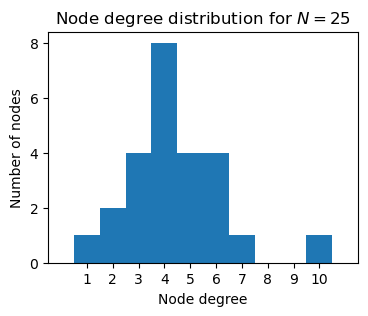

In [46]:
# for example: node degree
N=25; p=.2
G = ig.Graph.Erdos_Renyi(n=N, p=p)

fig, ax = plt.subplots(1,1,figsize=(4,3))

degrees = G.degree()
min_degree = min(degrees); max_degree = max(degrees)
bins = np.arange(min_degree, max_degree+2)-.5

ax.hist(degrees, bins=bins)
ax.set_xlim(min_degree-1.5, max_degree+1.5)
ax.set_xticks(bins[:-1]+.5)

ax.set_xlabel("Node degree")
ax.set_ylabel("Number of nodes")
ax.set_title(f"Node degree distribution for $N={N}$")

### _PageRank_

The PageRank values of the nodes in a graph were first defined by Larry Page to quantify the importance of a website. It is mathematically (and recursively) defined as
$$
PR(x_i) = \sum_{x_j \in \mathcal{N}(x_i)} \frac{PR(x_j)}{|\mathcal{N}(x_j)|},
$$
where $\mathcal{N}(x_i)$ represents the neighbourhood of node $x_i$, excluding $x_i$ itself. Note that for a fully-connected network consisting of $N$ nodes, this results in a PageRank of $1/N$ for each node.

One practical advantage of using PageRank is that it is very likely to assign a unique value to each node, even for graphs that are close to regular. One theoretical advantage is that 'the likelikehood to end up on a webpage' or the 'relevance of a webpage' may be an important indicator for how important this node is for the robustness of our entire NA. In other words, this is a good candidate for ordering our TEP.

Text(0.5, 1.0, 'PageRank distribution for $N=1000$\nContains 1000 unique values')

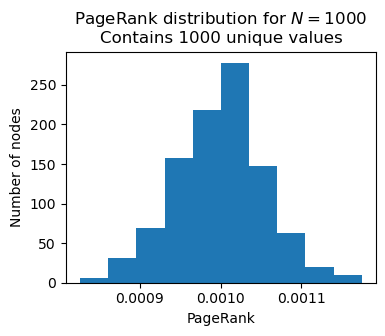

In [76]:
# for example: PageRank
N=1000; p=0.2
G = ig.Graph.Erdos_Renyi(n=N, p=p)

fig, ax = plt.subplots(1,1,figsize=(4,3))

PageRank = G.pagerank()
PageRank_unique = len(np.unique(np.array(PageRank)))

bins=20 # None
ax.hist(PageRank,bins=bins)

ax.set_xlabel("PageRank")
ax.set_ylabel("Number of nodes")
ax.set_title(f"PageRank distribution for $N={N}$\nContains {PageRank_unique} unique values")

### _Closeness_

Probably relevant as well: "Closeness centrality finds application in identifying individuals that are in a position to influence the entire network in the fastest way possible." (turing.com)

"Closeness was defined by Bavelas (1950) as the reciprocal of the farness" (Wikipedia), so, normalised over the number of nodes, we get
$$
C_B(x_i) = (N-1)\left(\sum_{0 \leq j < N}d(x_i, x_j)\right)^{-1},
$$
where $d(x_i, x_j)$ is the shortest path between nodes $x_i$ and $x_j$. A fully-connected graph therefore has a closeness of 1 for each nodes.

Due to the nature of its construction, this measure will not generate unique values for all nodes, which may be an issue when using this for ordering the nodes in a TEP.

Text(0.5, 1.0, 'Closeness distribution for $N=1000$\nContains 73 unique values')

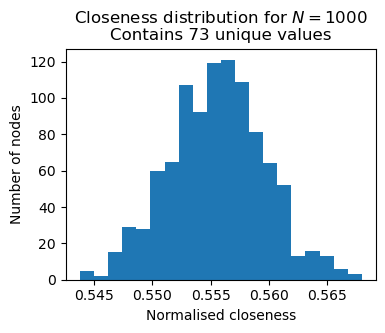

In [85]:
# example: closeness
N=1000; p=0.2
G = ig.Graph.Erdos_Renyi(n=N, p=p)

fig, ax = plt.subplots(1,1,figsize=(4,3))

closeness = G.closeness(normalized=True)
closeness_unique = len(np.unique(np.array(closeness)))

bins=20 # None
ax.hist(closeness,bins=bins)

ax.set_xlabel("Normalised closeness")
ax.set_ylabel("Number of nodes")
ax.set_title(f"Closeness distribution for $N={N}$\nContains {closeness_unique} unique values")

### _Similarity measures_

We can compare a node with all other nodes and give a score which quantifies how 'similar' they are, with some well-defined notion of similarity. This results in a similarity matrix $\Sigma$ with elements $\Sigma_{ij}$ for $0 \leq i,j < N$. The `igraph` package provides three variations:

1. _Jaccard similarity_: The Jaccard similarity coefficient of two vertices is the number of their common neighbors divided by the number of vertices that are adjacent to at least one of them.

2. _Dice similarity_: The Dice similarity coefficient of two vertices is twice the number of their common neighbors divided by the sum of their degrees. This
coefficient is very similar to the Jaccard coefficient, but usually gives higher similarities than its counterpart.

3. _Inverse log-weighted similarity_: Each vertex is assigned a weight which is 1 / log(degree). The log-weighted similarity of two vertices is the sum of the weights of their common neighbors.

Clearly, these measures generate a _vector_ per node, which is perhaps not ideal for ordering the nodes. Let's look at some other options.

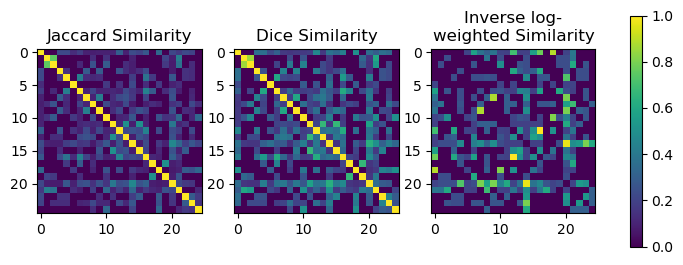

In [18]:
# for example: similarity measures
import igraph as ig
import matplotlib.pyplot as plt

N=25; p=.2
G = ig.Graph.Erdos_Renyi(n=N, p=p)

fig, axs = plt.subplots(1,3,figsize=(9,3))

jacc_sim = G.similarity_jaccard()
dice_sim = G.similarity_dice()
inverse_log = G.similarity_inverse_log_weighted()

im=axs[0].imshow(jacc_sim)
axs[1].imshow(dice_sim)
axs[2].imshow(inverse_log)

axs[0].set_title(f"Jaccard Similarity")
axs[1].set_title(f"Dice Similarity")
axs[2].set_title(f"Inverse log-\nweighted Similarity")

fig.colorbar(im, ax=axs.ravel().tolist())

## 2.4 - Assessing robustness by means of the Lyapunov spectrum

## 2.5 - Pipeline for computational experiments

(this is largely a transcription of the method expressed in the script, src and tests directories)

<hr>

# 3 - Results